In [9]:
import time
from PD_LMC.pd_lmc import PDLMC

def run_pdlmc_experiment(
    density,
    constraint,
    lr_x=1e-3,
    lr_lambda=0.5,
    num_particles=1,
    num_steps=10000,
    burn_in=2000,
    thin=1,
    slack=1e-3,
    lmc_steps_per_dual=1,
    store_every=1,
    output_filename="pdlmc_results.png",
    seed=0,
):
    print("=== Starting PD-LMC Experiment ===")
    print(f"-> particles/chains: {num_particles} | steps: {num_steps}")
    print(f"-> lr_x: {lr_x} | lr_lambda: {lr_lambda} | slack: {slack}")

    sampler = PDLMC(
        density=density,
        constraint=constraint,
        lr_x=lr_x,
        lr_lambda=lr_lambda,
        num_particles=num_particles,
    )

    start_time = time.time()
    sampler.run(
        num_steps=num_steps,
        slack=slack,
        lmc_steps_per_dual=lmc_steps_per_dual,
        store_every=store_every,
        seed=seed,
    )
    end_time = time.time()
    print(f"-> Sampling completed in {end_time - start_time:.2f} seconds.")

    sampler.plot_results_elipsoid(
        filename=output_filename,
        burn_in=burn_in // max(1, store_every),
        thin=max(1, thin),
        scatter_stride=200,
        limits=(-5, 5),
        truth_draws=100000,
        rej_draws=6000,
    )

    print("Experiment finished successfully!")
    return sampler

=== Starting PD-LMC Experiment ===
-> particles/chains: 1 | steps: 800000
-> lr_x: 0.001 | lr_lambda: 0.2 | slack: 0.001
-> Sampling completed in 122.20 seconds.
[Rejection] accepted_total=11934 / draws=100000 => acc_rate≈1.193e-01
True mean (rejection): [0.096983  1.0676795]
PD-LMC mean:          [0.04894051 0.9920874 ]
Saved to 'experiment_01_ellipsoid.png'.
Experiment finished successfully!


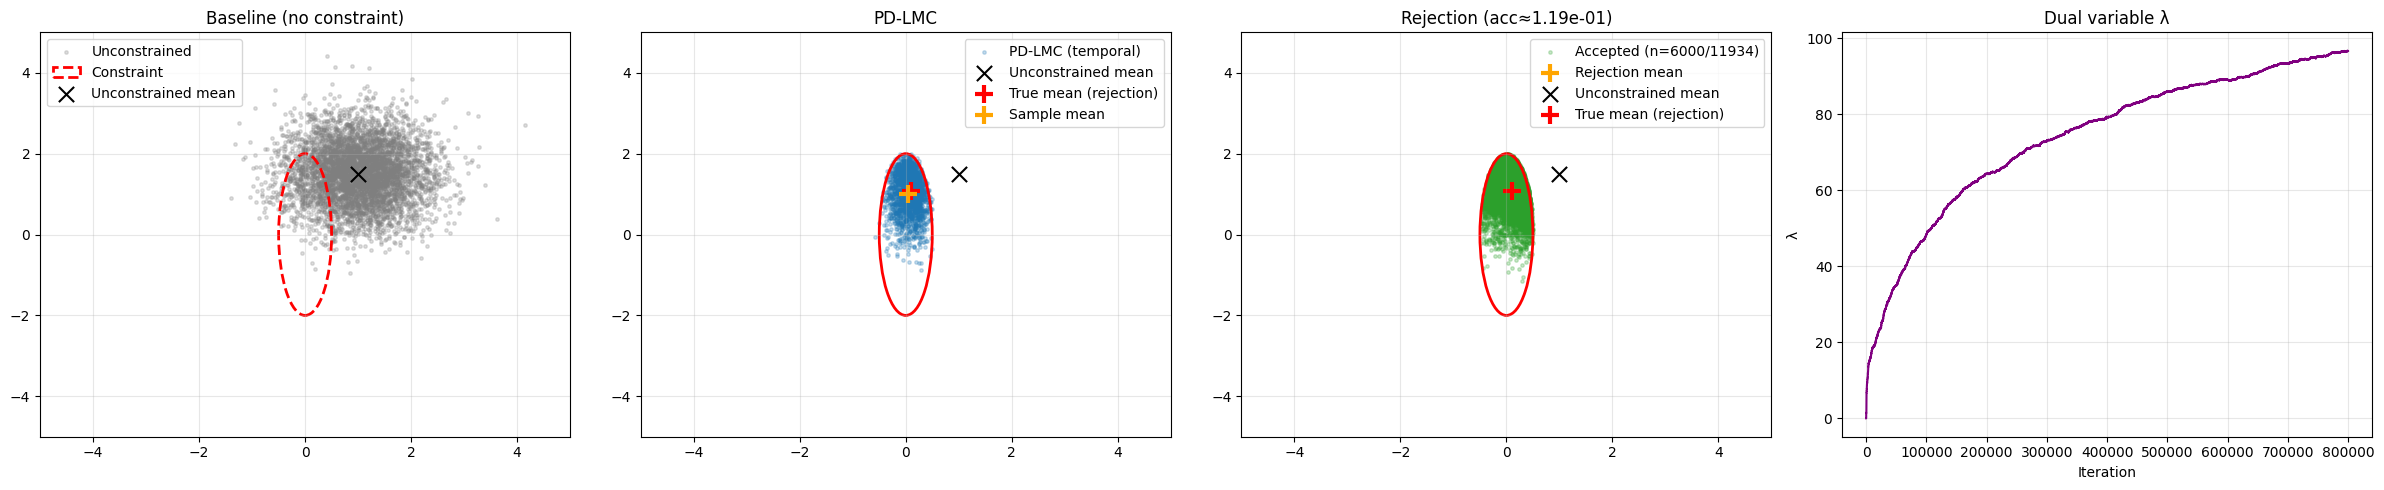

In [ ]:
from PD_LMC.constraint import EllipsoidConstraint
from PD_LMC.density import Gaussienne

# ==========================================
# 1) PARAMETER CONFIGURATION
# ==========================================
TARGET_MEAN = [1, 1.5]
COV_DEV = [[1, 0.0],
           [0.0, 1]]

# Ellipsoid: radial + center
RADIUS_X = 0.5
RADIUS_Y = 2.0
CENTER = (0.0, 0.0)

# Algorithm hyperparameters 
LR_X = 1e-3
LR_LAMBDA = 0.2      
SLACK = 1e-3

NUM_PARTICLES = 1     
NUM_STEPS = 800000   
BURN_IN =450000
THIN = 1
STORE_EVERY = 1       

OUTPUT_FILE = "experiment_01_ellipsoid.png"
SEED = 0

# ==========================================
# 2) OBJECT CREATION
# ==========================================
my_density = Gaussienne(mean=TARGET_MEAN, cov=COV_DEV)
my_constraint = EllipsoidConstraint(radius_x=RADIUS_X, radius_y=RADIUS_Y, center=CENTER)

# ==========================================
# 3) LAUNCH EXPERIMENT
# ==========================================
trained_sampler = run_pdlmc_experiment(
    density=my_density,
    constraint=my_constraint,
    lr_x=LR_X,
    lr_lambda=LR_LAMBDA,
    num_particles=NUM_PARTICLES,
    num_steps=NUM_STEPS,
    burn_in=BURN_IN,
    thin=THIN,
    slack=SLACK,
    lmc_steps_per_dual=1,     
    store_every=STORE_EVERY,
    output_filename=OUTPUT_FILE,
    seed=SEED,
)

=== Starting PD-LMC Experiment ===
-> particles/chains: 1 | steps: 800000
-> lr_x: 0.001 | lr_lambda: 0.2 | slack: 0.001
-> Sampling completed in 119.64 seconds.
[Rejection] accepted_total=1637 / draws=100000 => acc_rate≈1.637e-02
True mean (rejection): [0.3610853 0.3617824]
PD-LMC mean:          [0.34199136 0.33958676]
Saved to 'experiment_01_unit_ball.png'.
Experiment finished successfully!


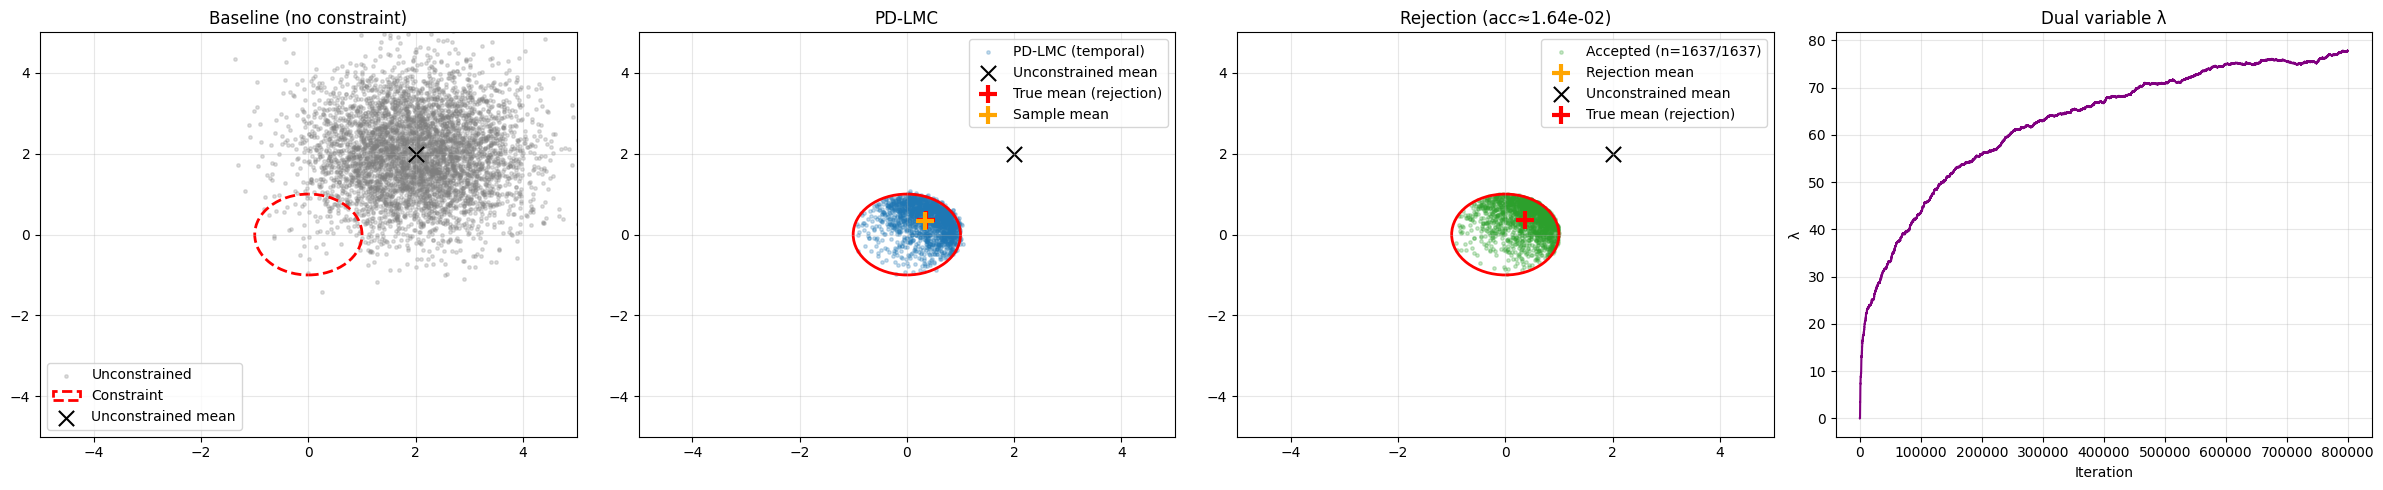

In [12]:
from PD_LMC.constraint import EllipsoidConstraint
from PD_LMC.density import Gaussienne

# ==========================================
# 1) PARAMETER CONFIGURATION
# ==========================================
TARGET_MEAN = [2, 2.0]
COV_DEV = [[1, 0.0],
           [0.0, 1]]

# Ellipsoid: radial + center
RADIUS_X = 1.0
RADIUS_Y = 1.0
CENTER = (0.0, 0.0)

# Algorithm hyperparameters 
LR_X = 1e-3
LR_LAMBDA = 0.2      
SLACK = 1e-3

NUM_PARTICLES = 1     
NUM_STEPS = 800000   
BURN_IN =450000
THIN = 1
STORE_EVERY = 1       

OUTPUT_FILE = "experiment_01_unit_ball.png"
SEED = 123

# ==========================================
# 2) OBJECT CREATION
# ==========================================
my_density = Gaussienne(mean=TARGET_MEAN, cov=COV_DEV)
my_constraint = EllipsoidConstraint(radius_x=RADIUS_X, radius_y=RADIUS_Y, center=CENTER)

# ==========================================
# 3) LAUNCH EXPERIMENT
# ==========================================
trained_sampler = run_pdlmc_experiment(
    density=my_density,
    constraint=my_constraint,
    lr_x=LR_X,
    lr_lambda=LR_LAMBDA,
    num_particles=NUM_PARTICLES,
    num_steps=NUM_STEPS,
    burn_in=BURN_IN,
    thin=THIN,
    slack=SLACK,
    lmc_steps_per_dual=1,     
    store_every=STORE_EVERY,
    output_filename=OUTPUT_FILE,
    seed=SEED,
)